In [3]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [9]:
import numpy as np
import matplotlib.cm as cm
import matplotlib.colors as colors
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D
import warnings; warnings.simplefilter('ignore')
import sys
import h5py
import pandas as pd
import seaborn as sns
sys.path.insert(0, '/Users/jsmonzon/Research/SatGen/mcmc/src/')
import jsm_ancillary
import jsm_visualize
import jsm_SHMR
import jsm_mcmc
import jsm_stats
import jsm_models
import jsm_halopull
import evolve as ev
import galhalo as gh
import profiles as profiles
import config as cfg
import init
import aux
from scipy import stats

In [10]:
plt.style.use('../../../SatGen/notebooks/paper1/paper.mplstyle')
double_textwidth = 7.0 #inches
single_textwidth = 3.5 #inches
levelz = [1-0.99, 1-0.95, 1-0.68]

In [11]:
early = jsm_visualize.Tree_Vis(file="../../../StellarHalo/data/four_examples/DF/early_evo.npz", merger_crit=-2, fesc=0.2, scatter=False, verbose=False)
hp = early.host_profiles[0]
sp = early.acc_profiles[14]

In [43]:
cmap = cm.viridis
z_vals = np.array([0, 2, 4, 6])
norm = mcolors.Normalize(vmin=z_vals.min(), vmax=z_vals.max())

In [44]:
worb0 = aux.SatelliteOrbit(hp, z=0, sp=sp, model="wetzel2011", N_samples=10000)
worb1 = aux.SatelliteOrbit(hp, z=1, sp=sp, model="wetzel2011", N_samples=10000)
worb2 = aux.SatelliteOrbit(hp, z=2, sp=sp, model="wetzel2011", N_samples=10000)
worb3 = aux.SatelliteOrbit(hp, z=3, sp=sp, model="wetzel2011", N_samples=10000)
worb4 = aux.SatelliteOrbit(hp, z=4, sp=sp, model="wetzel2011", N_samples=10000)

w_dataz = [worb0, worb1, worb2, worb3, worb4]

In [45]:
lorb0 = aux.SatelliteOrbit(hp, z=0, sp=sp, model="li2020", N_samples=10000)
lorb1 = aux.SatelliteOrbit(hp, z=1, sp=sp, model="li2020", N_samples=10000)
lorb2 = aux.SatelliteOrbit(hp, z=2, sp=sp, model="li2020", N_samples=10000)
lorb3 = aux.SatelliteOrbit(hp, z=3, sp=sp, model="li2020", N_samples=10000)
lorb4 = aux.SatelliteOrbit(hp, z=4, sp=sp, model="li2020", N_samples=10000)

l_dataz = [lorb0, lorb1, lorb2, lorb3, lorb4]

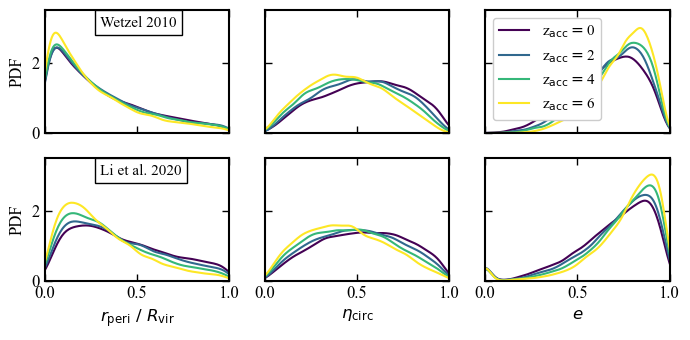

In [63]:
fig, axes = plt.subplots(2, 3, sharey=True, sharex=True, figsize=(double_textwidth, single_textwidth))

# --- plot with labels for legend ---
for mi, data in zip(z_vals, w_dataz):
    color = cmap(norm(mi))
    
    sns.kdeplot(data.get('r_peri_sampled'),
                ax=axes[0, 0],
                color=color,
                label="z$_{\\rm acc}=$"+f"{mi}")
    
    sns.kdeplot(data.get('eta_sampled'),
                ax=axes[0, 1],
                color=color)
    
    sns.kdeplot(data.get('eccentricity'),
                ax=axes[0, 2],
                color=color,
                label="z$_{\\rm acc}=$"+f"{mi}")
    

# --- plot with labels for legend ---
for mi, data in zip(z_vals, l_dataz):
    color = cmap(norm(mi))
    
    sns.kdeplot(data.get('r_peri_rvir'),
                ax=axes[1, 0],
                color=color,
                label="z$_{\\rm acc}=$"+f"{mi}")
    
    sns.kdeplot(data.get('circularity_E'),
                ax=axes[1, 1],
                color=color)
    
    sns.kdeplot(data.get('eccentricity'),
                ax=axes[1, 2],
                color=color)

# --- axeses formatting ---
axes[1, 0].set_xlim(0, 1)
axes[1, 1].set_xlim(0, 1)
axes[1, 2].set_xlim(0, 1)
axes[1, 0].set_ylim(0, 3.5)

axes[1, 0].set_xlabel(r"$r_{\rm peri}\ /\ R_{\rm vir}$")
axes[1, 1].set_xlabel(r"$\eta_{\rm circ}$")
axes[1, 2].set_xlabel(r"$e$")

axes[0,0].set_ylabel("PDF")
axes[1,0].set_ylabel("PDF")

axes[0,2].legend(fontsize=11, framealpha=1)
axes[0, 0].text(0.3, 0.865, s="Wetzel 2010", transform=axes[0, 0].transAxes, fontsize=11, bbox=dict(facecolor='white', alpha=1, edgecolor="k"))
axes[1, 0].text(0.3, 0.865, s="Li et al. 2020", transform=axes[1, 0].transAxes, fontsize=11, bbox=dict(facecolor='white', alpha=1, edgecolor="k"))

plt.tight_layout()
plt.savefig("../../figures/redshift_depedance.pdf", bbox_inches="tight")
plt.show()